# D5 — Developer Community Map (Leiden)

Reads Leiden community assignments from GCS and produces:
- Community size distribution
- Top communities by aggregate PageRank
- Intra-community degree analysis
- Community membership table

> **Privacy note**: developer identities are SHA-256 hashed; raw emails are never stored or displayed.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '../service-account-key.json'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

BUCKET = 'github-tech-trends-data'
sns.set_theme(style='whitegrid')
print('Environment ready.')

Environment ready.


## 1. Load data

In [2]:
df = pd.read_parquet(f'gs://{BUCKET}/processed/d5_communities/')
print(f'Developers: {len(df):,}')
print('Columns:', df.columns.tolist())

n_communities = df['community_id'].nunique()
print(f'Communities detected: {n_communities}')
df.head(5)

Developers: 10,000
Columns: ['dev_id', 'community_id', 'pagerank', 'degree']
Communities detected: 641


,dev_id,community_id,pagerank,degree
0,0009b72a02997374373565dbf0d65abc9b037f726ba830...,0,0.000041,32
1,00165af9cf528dc70997122def8c1686a5359b0e46b228...,1,0.000098,1509
2,001cb72943c7a1455b1db5ca40980493afb761e12be1ca...,7,0.000115,64
3,002078f17892e31746cd98153f3b6b573c48e0096ddc52...,0,0.000071,20
4,002d7bea94dc000625eb1ae53ca734148351d4ba6a2ae2...,3,0.000019,5


## 2. Community size distribution

Largest community : 5,264 members
Median comm. size : 1 members
Singleton comms   : 485


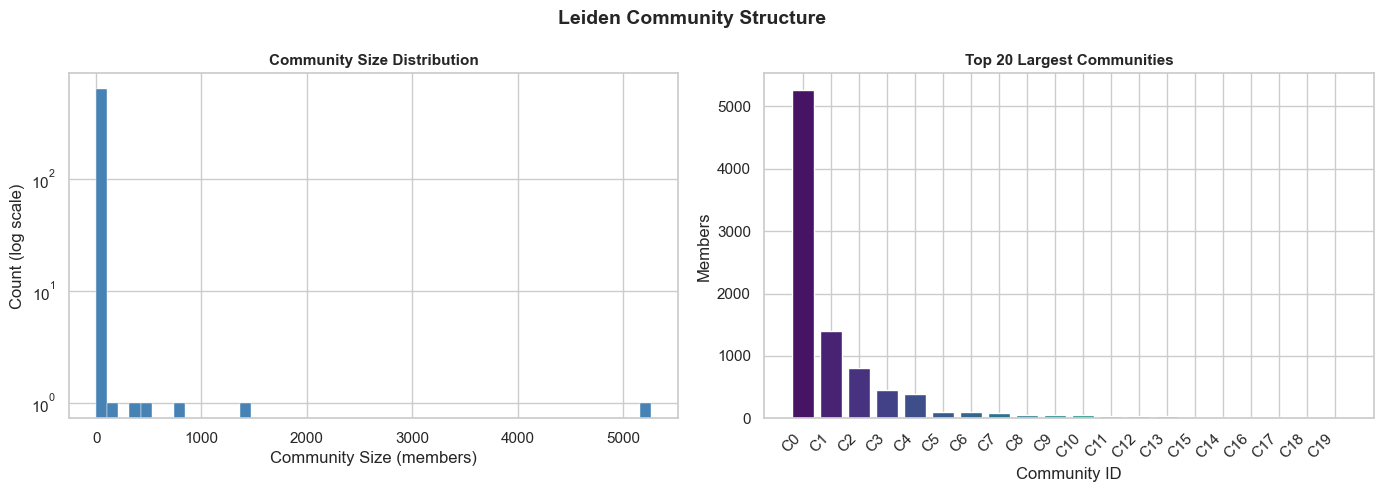

In [3]:
community_sizes = df.groupby('community_id').size().sort_values(ascending=False)

print(f'Largest community : {community_sizes.iloc[0]:,} members')
print(f'Median comm. size : {community_sizes.median():.0f} members')
print(f'Singleton comms   : {(community_sizes == 1).sum()}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution histogram
ax1.hist(community_sizes.values, bins=50, color='steelblue',
         edgecolor='white', linewidth=0.3, log=True)
ax1.set_xlabel('Community Size (members)')
ax1.set_ylabel('Count (log scale)')
ax1.set_title('Community Size Distribution', fontsize=11, fontweight='bold')

# Top-20 largest communities bar
top20_sizes = community_sizes.head(20)
ax2.bar(range(len(top20_sizes)), top20_sizes.values,
        color=sns.color_palette('viridis', len(top20_sizes)))
ax2.set_xticks(range(len(top20_sizes)))
ax2.set_xticklabels([f'C{c}' for c in top20_sizes.index], rotation=45, ha='right')
ax2.set_xlabel('Community ID')
ax2.set_ylabel('Members')
ax2.set_title('Top 20 Largest Communities', fontsize=11, fontweight='bold')

plt.suptitle('Leiden Community Structure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d5_community_sizes.png', dpi=150)
plt.show()

## 3. Community influence — aggregate PageRank

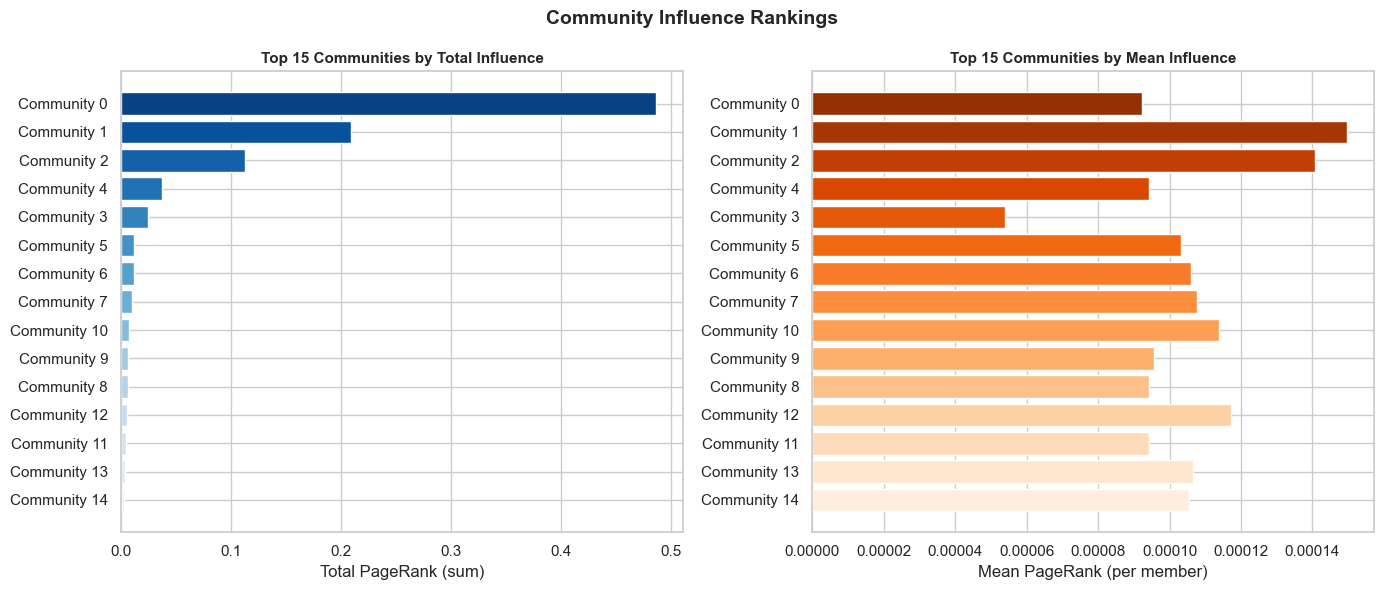

In [4]:
comm_stats = (
    df.groupby('community_id')
    .agg(
        size=('dev_id', 'count'),
        total_pagerank=('pagerank', 'sum'),
        mean_pagerank=('pagerank', 'mean'),
        max_pagerank=('pagerank', 'max'),
        mean_degree=('degree', 'mean'),
    )
    .sort_values('total_pagerank', ascending=False)
    .reset_index()
)

top15_influence = comm_stats.head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(
    [f'Community {c}' for c in top15_influence['community_id']],
    top15_influence['total_pagerank'],
    color=sns.color_palette('Blues_r', 15),
)
ax1.invert_yaxis()
ax1.set_xlabel('Total PageRank (sum)')
ax1.set_title('Top 15 Communities by Total Influence', fontsize=11, fontweight='bold')

ax2.barh(
    [f'Community {c}' for c in top15_influence['community_id']],
    top15_influence['mean_pagerank'],
    color=sns.color_palette('Oranges_r', 15),
)
ax2.invert_yaxis()
ax2.set_xlabel('Mean PageRank (per member)')
ax2.set_title('Top 15 Communities by Mean Influence', fontsize=11, fontweight='bold')

plt.suptitle('Community Influence Rankings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d5_community_influence.png', dpi=150)
plt.show()

## 4. Size vs Influence bubble chart

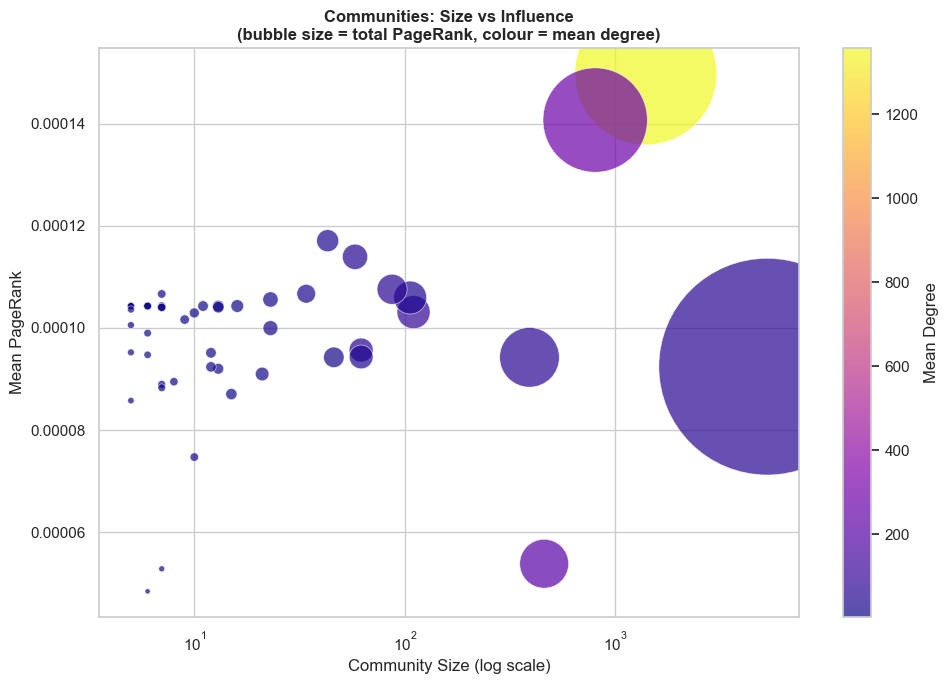

In [5]:
# Only communities with ≥5 members
big = comm_stats[comm_stats['size'] >= 5].copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    big['size'], big['mean_pagerank'],
    s=big['total_pagerank'] * 5e4,
    c=big['mean_degree'], cmap='plasma',
    alpha=0.7, edgecolors='white', linewidths=0.5,
)
plt.colorbar(scatter, ax=ax, label='Mean Degree')
ax.set_xscale('log')
ax.set_xlabel('Community Size (log scale)')
ax.set_ylabel('Mean PageRank')
ax.set_title('Communities: Size vs Influence\n'
             '(bubble size = total PageRank, colour = mean degree)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d5_size_vs_influence.png', dpi=150)
plt.show()

## 5. Community composition heatmap (degree × PageRank)

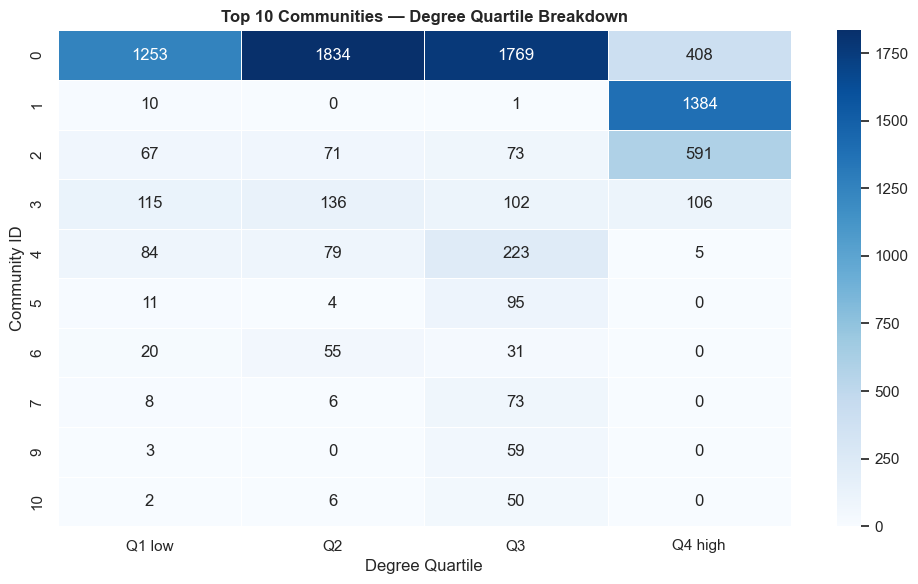

In [6]:
# Bin developers into degree quartiles
df['degree_q'] = pd.qcut(df['degree'], q=4,
                          labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
df['pr_q']     = pd.qcut(df['pagerank'], q=4,
                          labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])

# Only top-10 communities by total pagerank
top10_comms = comm_stats.head(10)['community_id'].tolist()
heat_df = df[df['community_id'].isin(top10_comms)]

pivot = (
    heat_df.groupby(['community_id', 'degree_q'])
    .size()
    .unstack('degree_q')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Top 10 Communities — Degree Quartile Breakdown',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Degree Quartile')
ax.set_ylabel('Community ID')
plt.tight_layout()
plt.savefig('../outputs/d5_community_heatmap.png', dpi=150)
plt.show()

## 6. Community stats summary table

In [7]:
comm_stats.head(20).style \
    .background_gradient(subset=['total_pagerank', 'mean_pagerank'], cmap='Blues') \
    .background_gradient(subset=['size'], cmap='Greens') \
    .format({'total_pagerank': '{:.6f}', 'mean_pagerank': '{:.8f}',
             'max_pagerank': '{:.8f}', 'mean_degree': '{:.1f}'})

,community_id,size,total_pagerank,mean_pagerank,max_pagerank,mean_degree
0,0,5264,0.486553,0.00009243,0.00102508,62.0
1,1,1395,0.208931,0.00014977,0.00032832,1357.9
2,2,802,0.112848,0.00014071,0.00052175,279.1
3,4,391,0.036855,0.00009426,0.00038620,61.5
4,3,459,0.024720,0.00005386,0.00027300,211.5
5,5,110,0.011342,0.00010311,0.00017648,83.4
6,6,106,0.011232,0.00010596,0.00025018,36.0
7,7,87,0.009359,0.00010758,0.00014971,60.7
8,10,58,0.006608,0.00011393,0.00015660,50.2
9,9,62,0.005932,0.00009568,0.00011737,58.9
